In [29]:
import pandas as pd 
import numpy as np
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score,confusion_matrix,roc_curve,auc
from imblearn.over_sampling import SMOTE
from geopy.distance import geodesic
import joblib

In [30]:
df=pd.read_csv("creditcard.csv")

print("datset loaded successfully!")
print("Shape:",df.shape)

df.head()

datset loaded successfully!
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [31]:
print("Dataset Information:")
print()

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:

Rows: 284807
Columns: 31

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing Values:
0

Duplicate Rows:
1081


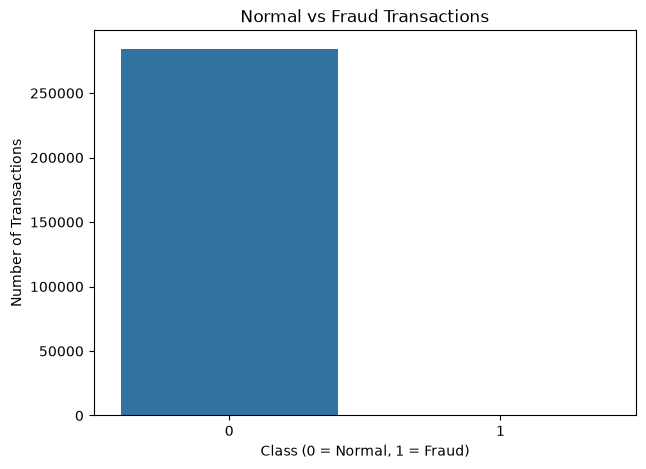

In [32]:
plt.figure(figsize=(7,5))

sns.countplot(x="Class", data=df)

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

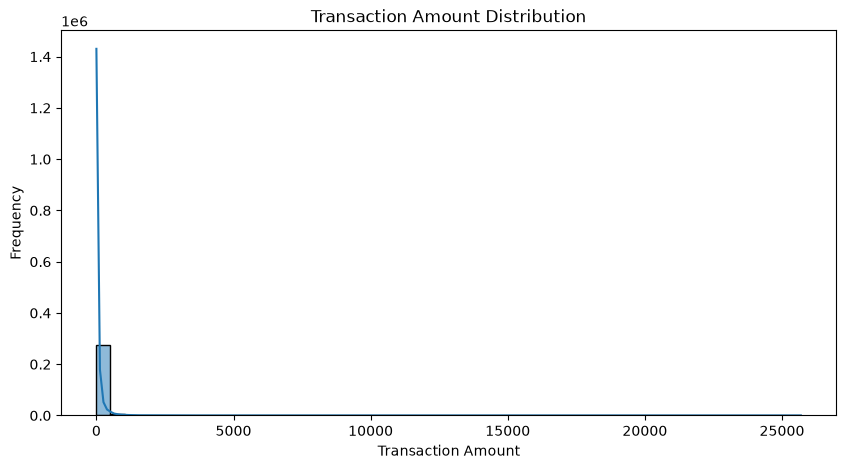

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Amount",
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [34]:
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

print("Normal transactions:", len(normal))
print("Fraud transactions:", len(fraud))

print("\nAverage Normal Transaction Amount:",
      normal["Amount"].mean())

print("Average Fraud Transaction Amount:",
      fraud["Amount"].mean())

Normal transactions: 284315
Fraud transactions: 492

Average Normal Transaction Amount: 88.29102242231328
Average Fraud Transaction Amount: 122.21132113821139


In [35]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

Training data: (227845, 30)
Testing data: (56962, 30)

Training target:
Class
0    227451
1       394
Name: count, dtype: int64


In [37]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train_smote
)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [40]:
print("LOGISTIC REGRESSION")
print("=" * 50)

print(
    classification_report(
        y_test,
        logistic_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, logistic_prob)
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC: 0.9764816590676788


In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [43]:
print("RANDOM FOREST")
print("=" * 50)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf_prob)
)

RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.82      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9664616901909893


In [44]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train
)

lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]

print("LightGBM trained successfully!")

LightGBM trained successfully!


In [45]:
print("LIGHTGBM")
print("=" * 50)

print(
    classification_report(
        y_test,
        lgb_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, lgb_prob)
)

LIGHTGBM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.76      0.76        98

    accuracy                           1.00     56962
   macro avg       0.89      0.88      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9197038691672504


In [46]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [47]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "LightGBM"
    ],

    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lgb_pred)
    ],

    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, lgb_pred)
    ],

    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, lgb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, lgb_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, lgb_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.989853,0.134146,0.897959,0.233422,0.976482
1,Random Forest,0.999333,0.800000,0.816327,0.808081,0.966462
2,LightGBM,0.999192,0.770833,0.755102,0.762887,0.919704


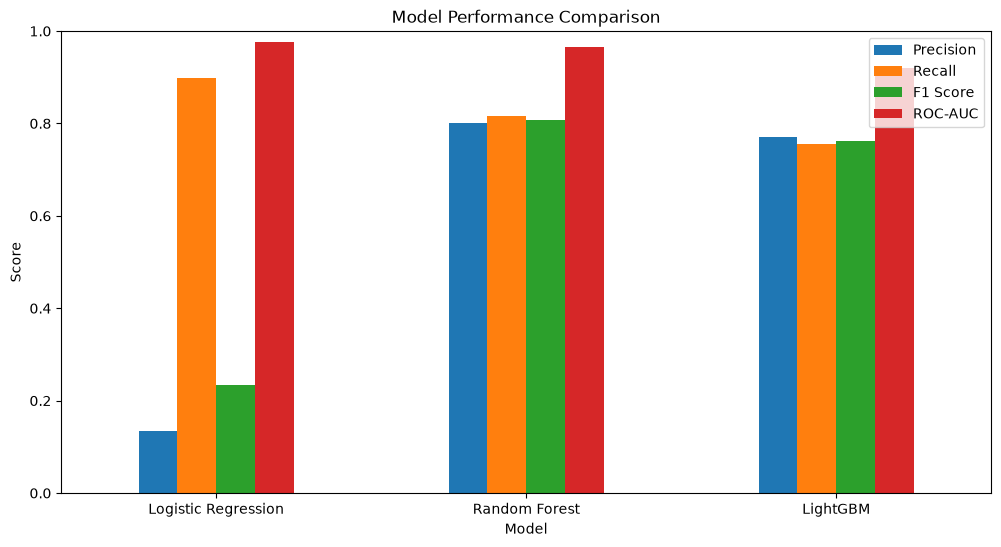

In [48]:
results.set_index("Model")[
    ["Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

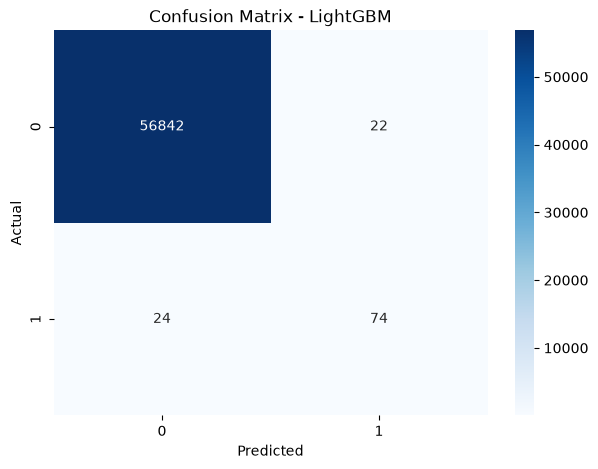

In [49]:
cm = confusion_matrix(
    y_test,
    lgb_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

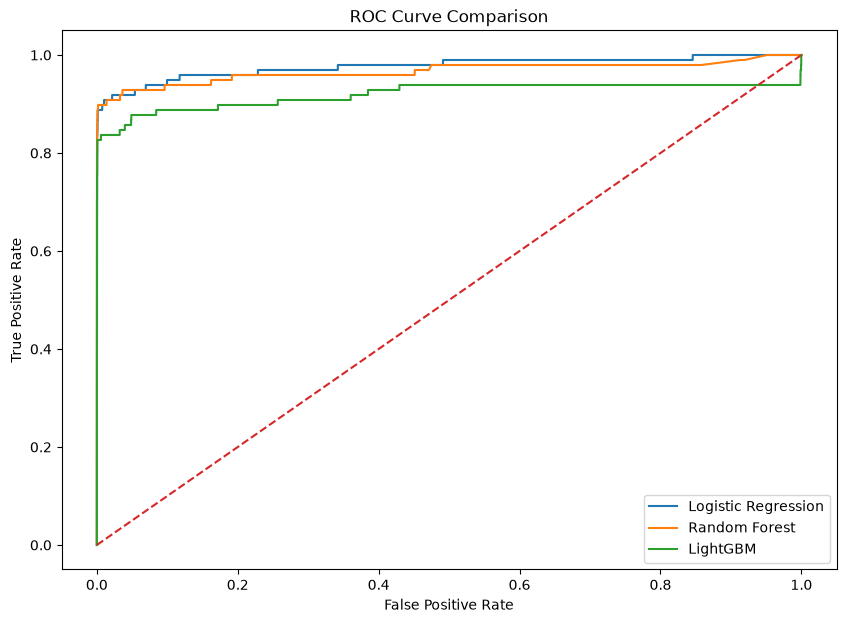

In [50]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    logistic_prob
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_prob
)

fpr_lgb, tpr_lgb, _ = roc_curve(
    y_test,
    lgb_prob
)

plt.figure(figsize=(10,7))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot(
    fpr_lgb,
    tpr_lgb,
    label="LightGBM"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [51]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
0,Time,468
4,V4,447
24,V24,392
29,Amount,369
26,V26,368
12,V12,364
13,V13,352
14,V14,348
18,V18,330
8,V8,319


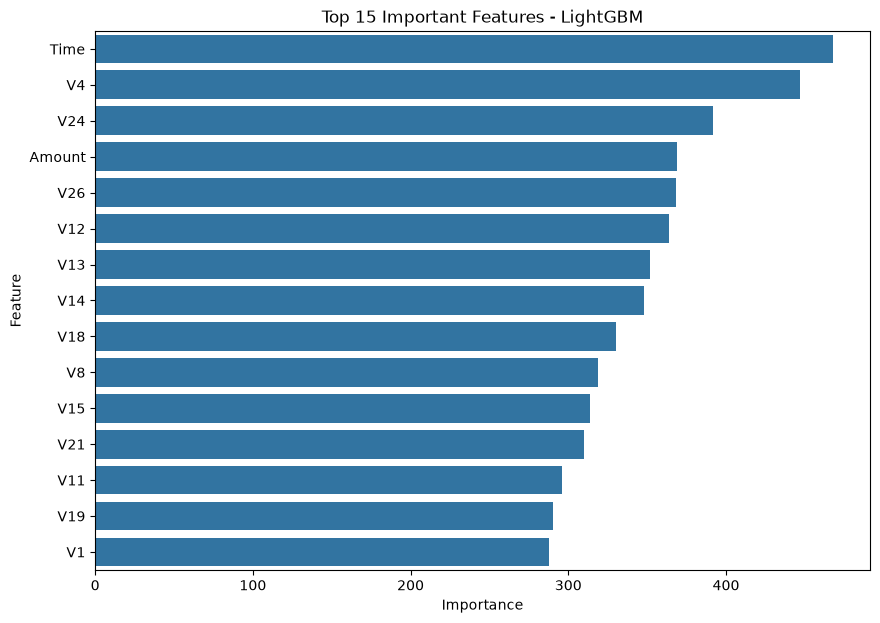

In [52]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - LightGBM")

plt.show()

In [53]:
def predict_fraud(transaction):

    transaction = np.array(transaction).reshape(1, -1)

    prediction = lgb_model.predict(transaction)[0]

    probability = lgb_model.predict_proba(
        transaction
    )[0][1]

    if prediction == 1:
        result = "FRAUD TRANSACTION"
    else:
        result = "NORMAL TRANSACTION"

    print("Prediction:", result)
    print("Fraud Probability:", round(probability * 100, 2), "%")

    return prediction, probability

In [54]:
sample_transaction = X_test.iloc[0].values

predict_fraud(sample_transaction)

Prediction: NORMAL TRANSACTION
Fraud Probability: 0.0 %


c:\Users\Dell\OneDrive\Desktop\creditcardfrauddetection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Dell\OneDrive\Desktop\creditcardfrauddetection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(np.int64(0), np.float64(3.090332335726863e-08))

In [55]:
joblib.dump(
    lgb_model,
    "credit_card_fraud_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [56]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!
